In [135]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)

data_path = scoob_llowfsc.path/'exp-data'

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3, imshow
from scoob_llowfsc import utils
from scoob_llowfsc import iefc
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9

/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


In [136]:
scoobi.home_block(client0)

In [138]:
scoobi.move_block_out(client0)

In [137]:
reload(scoobi)
xc, yc = (4200, 2950)
npsf = 256
scoobi.set_camsci_roi(xc, yc, npsf, client0)


In [139]:
reload(scoobi)
scoobi.set_camsci_blacklevel(1, client0)

Set the CAMSCI blacklevel to 1.0


In [140]:
reload(scoobi)
camsci_channel = 'camsci'
dm_howfsc_channel = 'dm00disp03'

I = scoobi.SCOOBI(camsci_channel=camsci_channel, dm_channel=dm_howfsc_channel)

# Do the normalization

In [144]:
scoobi.move_psf(50, 0, client0)

In [86]:
scoobi.move_psf(0, -50, client0)

In [145]:
reload(scoobi)
I.set_camsci_exp_time(0.000120, client0)

Set the ZWO exposure time to 1.20e-04s


In [146]:
reload(scoobi)
I.set_camsci_gain(120, client0)

Set the ZWO gain setting to 120.0


In [147]:
reload(scoobi)
I.set_fib_atten(25, client)

Set the fiber attenuation to 25.0


INFO:utils:Got semaphore index 1.


21955.36
0


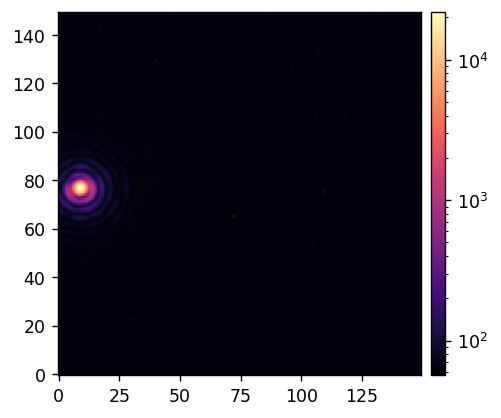

In [148]:
I.NCAMSCI = 200
I.subtract_dark = False
I.return_ni = False

ref_psf = I.snap_camsci()
print(xp.max(ref_psf))
imshow([ref_psf], norms=[LogNorm()], cmaps=['magma'])


In [150]:
I.camsci_ref_params = {
    'ref_psf':copy.copy(ref_psf),
    'Imax': copy.copy(xp.max(ref_psf)),
    'texp': copy.copy(I.texp), 
    'atten': copy.copy(I.atten),
    'gain': copy.copy(I.gain),
}
utils.save_pickle(data_path/f'{today}_ref_psf_params.pkl', I.camsci_ref_params)

# I.camsci_ref_params = utils.load_pickle(data_path/f'{today}_ref_psf_params.pkl')

print(I.camsci_ref_params)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/20250319_ref_psf_params.pkl
{'ref_psf': array([[62.62, 64.62, 64.86, ..., 64.22, 63.74, 64.26],
       [65.02, 64.7 , 65.34, ..., 64.04, 63.54, 67.74],
       [65.22, 64.1 , 64.98, ..., 64.18, 64.4 , 64.8 ],
       ...,
       [62.42, 64.5 , 65.74, ..., 64.44, 64.74, 64.04],
       [63.42, 63.6 , 64.74, ..., 64.48, 63.38, 66.42],
       [62.52, 64.4 , 65.08, ..., 65.64, 64.12, 64.9 ]]), 'Imax': array(21955.36), 'texp': 0.00012, 'atten': 25, 'gain': 120}


# Move back onto the vortex and adjust exposure times

In [179]:
scoobi.move_psf(2, 0, client0)

In [175]:
scoobi.move_psf(0, -2, client0)

In [34]:
I.reset_dm()

In [163]:
I.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


In [164]:
I.set_camsci_exp_time(0.0005, client0)

Set the ZWO exposure time to 5.00e-04s


In [165]:
I.set_camsci_gain(120, client0)

Set the ZWO gain setting to 120.0


# Make a function to adjust bias on the camera
camsci.blacklevel.target

In [60]:
reload(scoobi)
scoobi.move_block_in(client0)

0


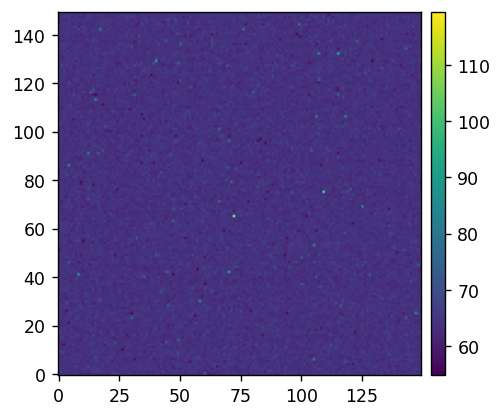

In [180]:
# I.NCAMSCI = 200
# I.subtract_dark = False
# I.return_ni = False
# dark_frame = I.snap_camsci()
# utils.save_pickle(data_path/f'{today}_camsci_dark_frame_{I.texp:.6f}.pkl', dark_frame)
# I.df = copy.copy(dark_frame)

dark_frame = utils.load_pickle(data_path/f'{today}_camsci_dark_frame_{I.texp:.6f}.pkl')
I.df = copy.copy(dark_frame)

imshow([I.df])

In [63]:
reload(scoobi)
scoobi.move_block_out(client0)

0


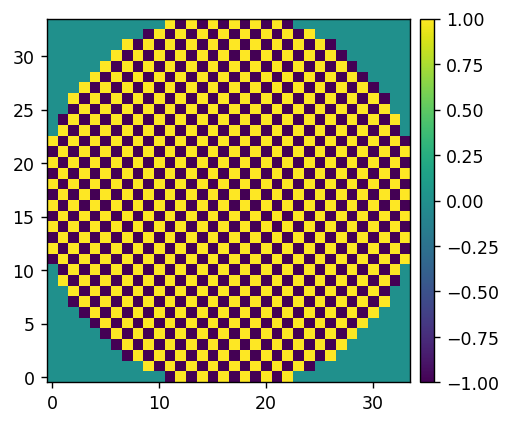

In [181]:
reload(scoobi.utils)
waffle_command = utils.make_fourier_command(x_cpa=17, y_cpa=17) * xp.array(I.dm_mask)
imshow([waffle_command])

100
0


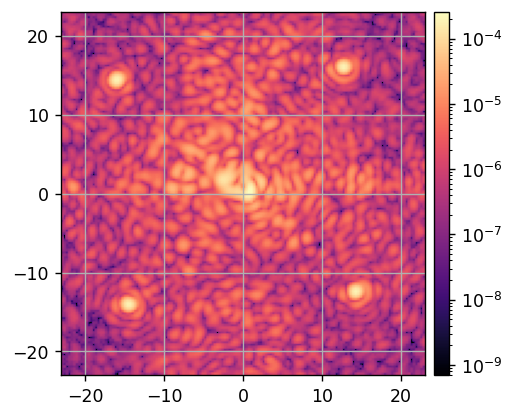

In [182]:
I.set_dm(10e-9 * waffle_command)
I.x_shift = 0
I.y_shift = 0

I.NCAMSCI = 100
I.subtract_dark = True
I.return_ni = True
waffle_im = I.snap_camsci()
imshow([waffle_im], norms=[LogNorm()], cmaps=['magma'], grids=[1], pxscls=[I.camsci_pxscl_lamDc])

Centroids:
 [[ 27.39255955  28.58059932]
 [ 22.68630388 121.16615623]
 [115.99977066 126.49158175]
 [121.02911183  33.95851078]
 [ 27.39255955  28.58059932]]


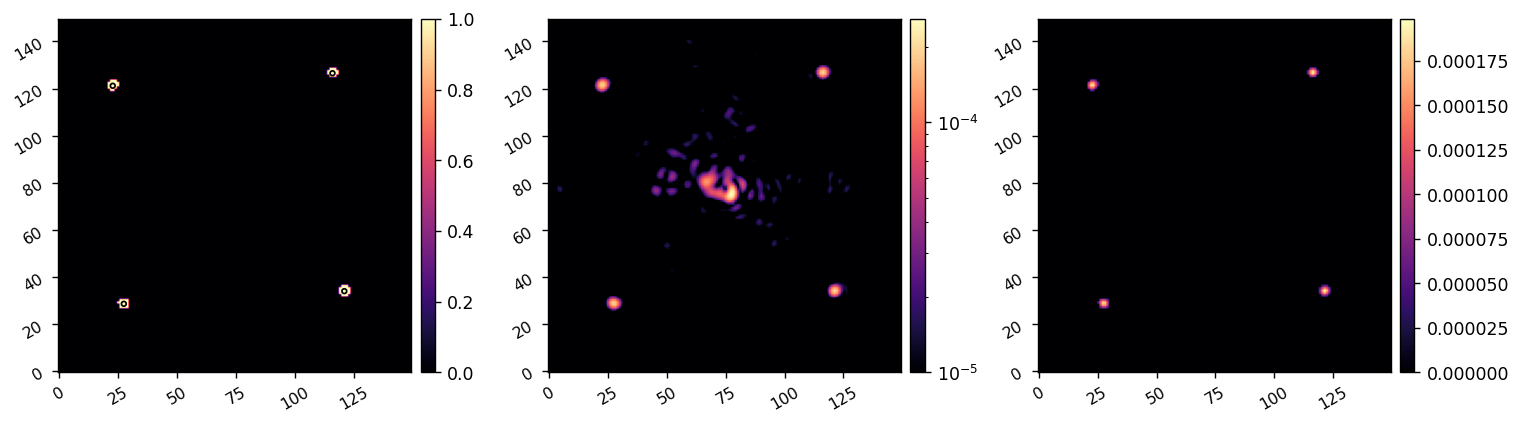

Angle:  86.85638953097478
Measured center in X:  71.78126246611278
Measured center in Y:  77.63012313319092
Required shift in X:  3.0
Required shift in Y:  -3.0


In [ ]:
reload(utils)

# xshift,yshift,angle = scoobi.utils.measure_center_and_angle(waffle_im, I.psf_pixelscale_lamDc, im_thresh=5e-5, r_thresh=16)
xshift, yshift, angle = utils.measure_center_and_angle(
    waffle_im, 
    I.camsci_pxscl_lamDc, 
    im_thresh=5e-5, 
    r_thresh=16,
)

363


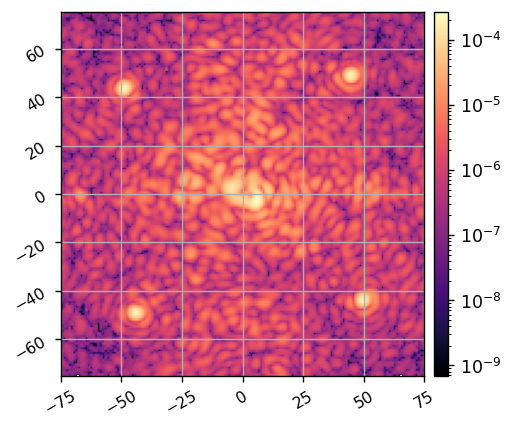

In [188]:
I.NCAMSCI = 50
I.npsf = 150
I.camsci_x_shift = xshift
I.camsci_y_shift = yshift

I.subtract_dark = True
I.return_ni = True

coro_im = I.snap_camsci()
imshow1(coro_im, lognorm=True, pxscl=1, grid=True)

In [189]:
I.zero_dm()

# Choose modes and probes for iEFC

1022
0


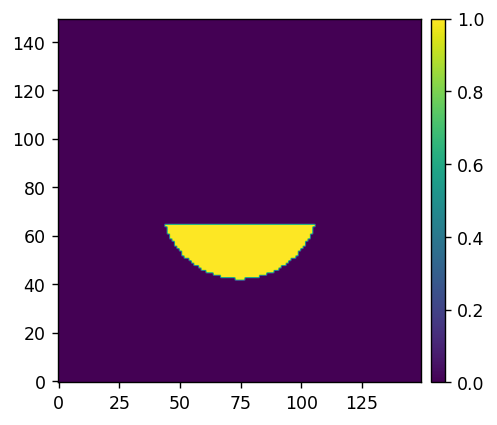

In [192]:
reload(utils)

iwa = 3
owa = 10
rotation = 90
control_mask = utils.create_annular_focal_plane_mask(
    I.npsf, 
    I.camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    rotation=rotation,
)
print(control_mask.sum())
imshow([control_mask])

391
2.8908676070198727e-06
1


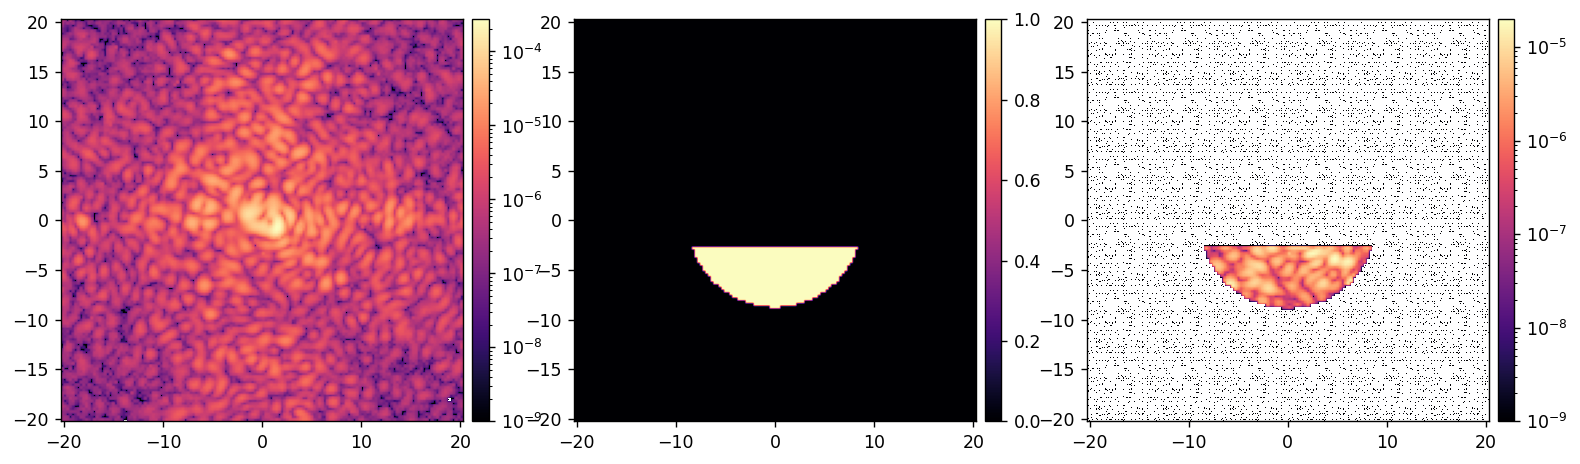

In [ ]:
I.zero_dm()
I.NCAMSCI = 50
I.subtract_dark = True
I.return_ni = True
# I.set_zwo_exp_time(0.0005, client0)

ref_coro_im = I.snap_camsci()
print(xp.mean(ref_coro_im[control_mask]))
imshow(
    [ref_coro_im, control_mask, control_mask * ref_coro_im],
    norms=[LogNorm(1e-9), None, LogNorm(1e-9)],
    pxscls=[I.camlo_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)

1


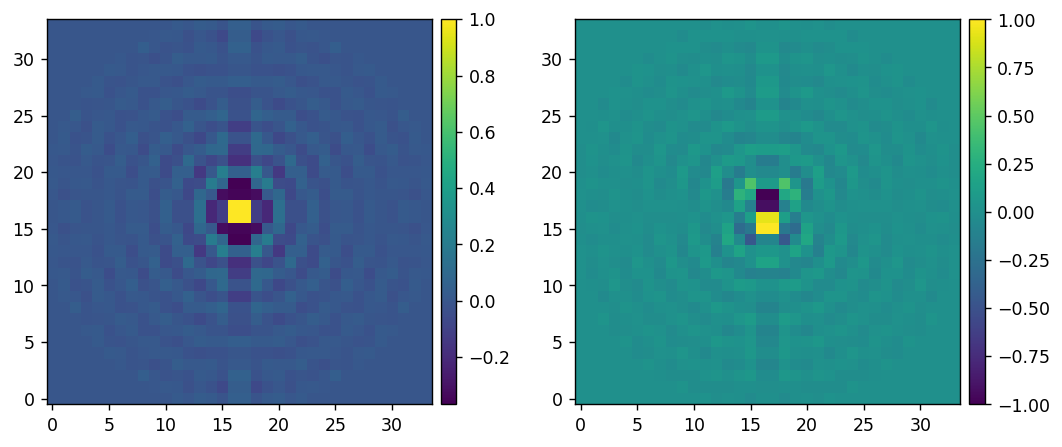

In [198]:
reload(utils)
probe_iwa = iwa - 0.5
probe_owa = owa + 2

fourier_probes = utils.create_fourier_probes(
    xp.array(I.dm_mask), 
    I.npsf, 
    I.camsci_pxscl_lamDc,
    probe_iwa,
    probe_owa,
    # edge=iwa-0.5,
    fourier_sampling=0.75, 
    # rotation=90,
    nprobes=2,
    # plot=True,
    use_weighting=True
)
fourier_probes[0] = xp.rot90(fourier_probes[0])
fourier_probes[1] = xp.rot90(fourier_probes[1])

imshow([fourier_probes[0], fourier_probes[1]])

In [ ]:
I.N

1


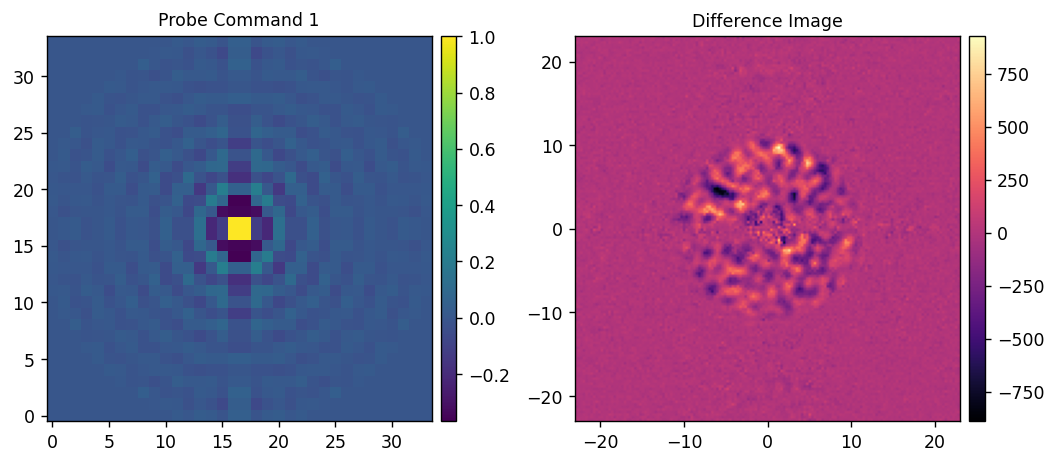

1


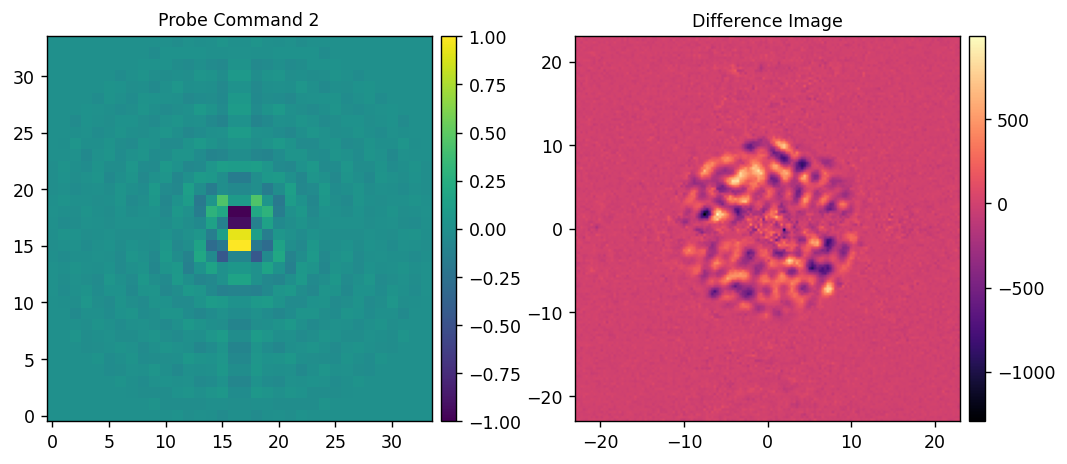

1


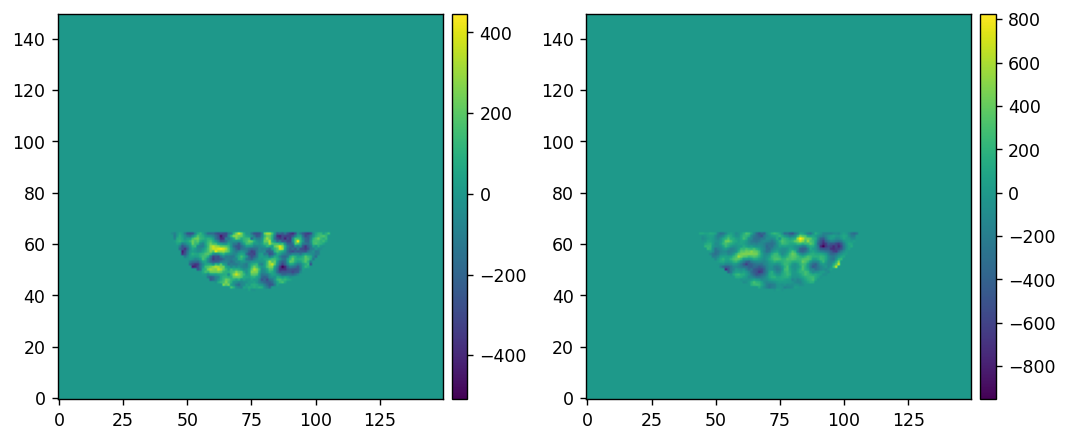

In [203]:
reload(iefc)

# time.sleep(3)
I.NCAMSCI = 20
I.subtract_dark = False
I.return_ni = True

diff_ims = iefc.take_measurement(
    I, 
    fourier_probes, 
    3e-9, 
    plot=True,
)
diff_ims *= control_mask
imshow([diff_ims[0], diff_ims[1]])
# imshow3(diff_ims[0], diff_ims[1], diff_ims[2])

1


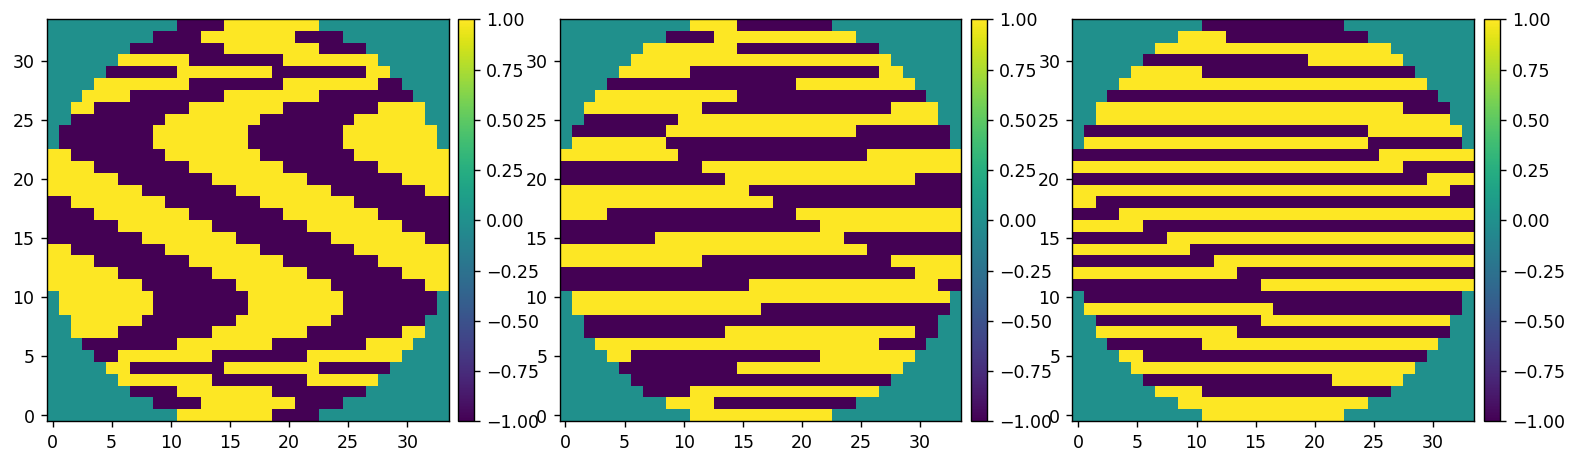

In [206]:
reload(utils)
calib_modes = utils.create_hadamard_modes(xp.array(I.dm_mask))
imshow(
    [calib_modes[8], calib_modes[80], calib_modes[800]]
)


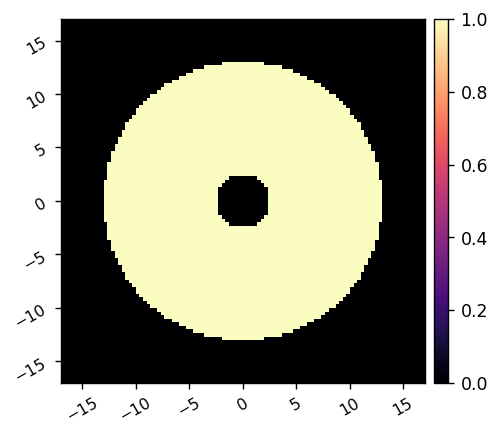

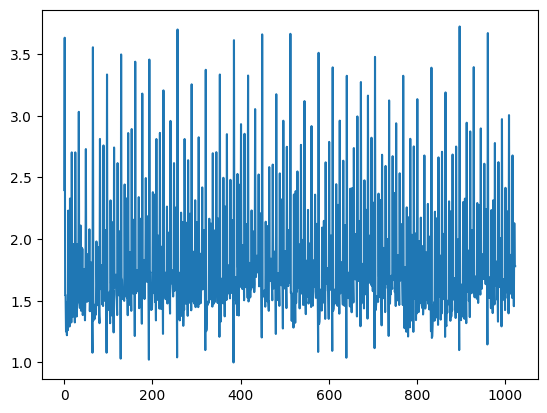

[1.26141126 2.2314004  1.69366311 1.7770875 ]


In [207]:
reload(iefc)
scale_factors = iefc.compute_hadamard_scale_factors(calib_modes, scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)
print(scale_factors[8:12])

In [89]:
I.zero_dm()

0.001
Calibrating iEFC...
	Calibrated mode 1024/1024 in 1171.969s
Calibration complete.
1


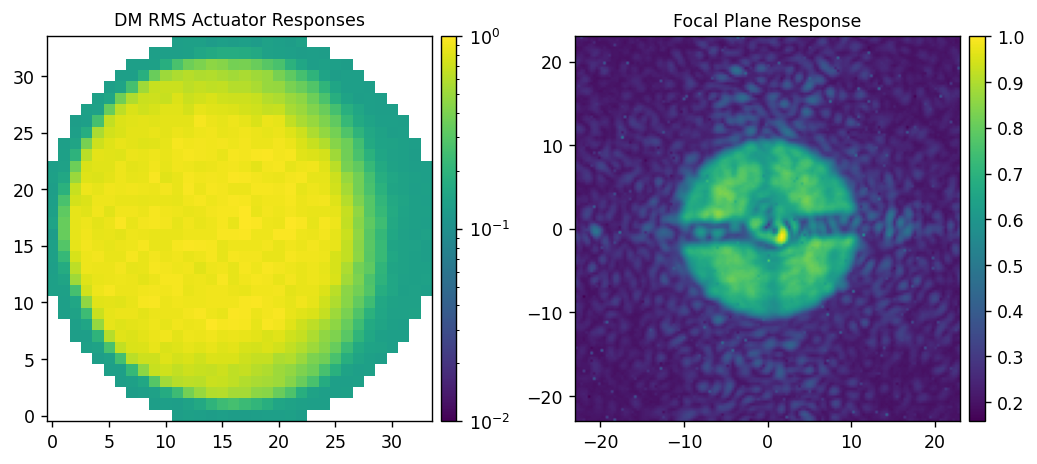

In [210]:
reload(iefc)
I.zero_dm()

probe_amp = 3e-9
calib_amp = 2e-9

I.NCAMSCI = 20
I.return_ni = True
I.subtract_dark = False
I.dm_delay = I.texp * 2
print(I.dm_delay)

# time.sleep(2)
response_matrix, response_cube = iefc.calibrate(
    I, 
    control_mask, 
    probe_amp, 
    fourier_probes, 
    calib_amp, 
    calib_modes[:], 
    scale_factors=scale_factors, 
#  calib_amp, calib_modes[100:110], 
#  scale_factors=scale_factors[100:110], 
#  calib_amp, calib_modes[8:12], 
#  scale_factors=scale_factors[8:12], 
    plot_responses=1, 
)

In [211]:
iefc_calib_data = {
    'response_matrix':response_matrix,
    'response_cube':response_cube,
    'control_mask':control_mask,
    'NCAMSCI':I.NCAMSCI,
    'probe_amp':probe_amp,
    'probe_modes':fourier_probes,
    'calib_amp':calib_amp,
    'scale_factors':scale_factors,
}
utils.save_pickle(data_path/f'{today}_iefc_calib.pkl', iefc_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/20250319_iefc_calib.pkl


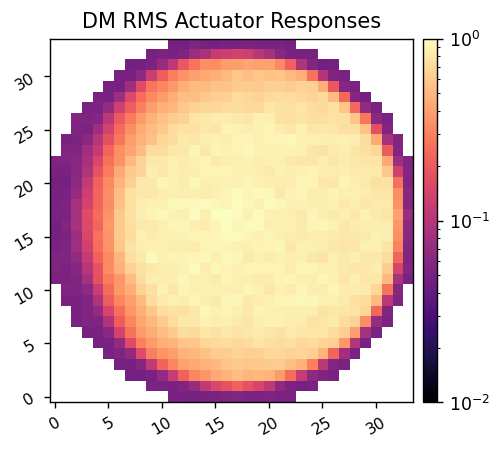

In [159]:
calib_data = utils.load_pickle(f'data/{today}_iefc_calib.pkl')
response_cube = calib_data['response_cube']
response_matrix = response_cube[:, :, control_mask.ravel()].reshape(1024, -1).T

dm_response_map = xp.sqrt(xp.mean(xp.square(response_matrix.dot(calib_modes.reshape(1024, -1))), axis=0))
dm_response_map = dm_response_map.reshape(I.Nact,I.Nact) / xp.max(dm_response_map)
imshow1(dm_response_map, 'DM RMS Actuator Responses', lognorm=True, vmin=1e-2)

In [239]:
cm25 = utils.beta_reg(response_matrix, -2.5)
cm50 = utils.beta_reg(response_matrix, -5)
cm60 = utils.beta_reg(response_matrix, -6)


In [223]:
I.set_fib_atten(15, client)
I.set_camsci_exp_time(0.1, client0)

Set the fiber attenuation to 15.0
Set the ZWO exposure time to 1.00e-01s


In [216]:
reload(scoobi)
scoobi.move_block_in(client0)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/20250319_camsci_dark_frame_0.100000.pkl
0


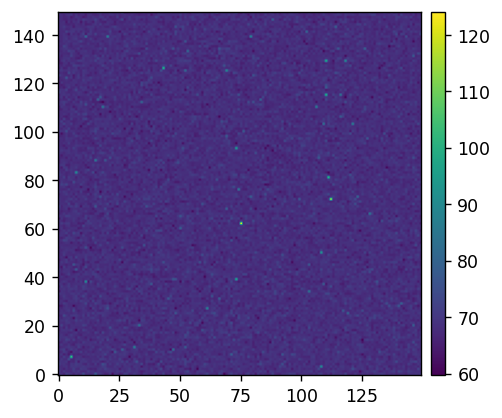

In [218]:
I.NCAMSCI = 100
I.subtract_dark = False
I.return_ni = False
dark_frame = I.snap_camsci()
utils.save_pickle(data_path/f'{today}_camsci_dark_frame_{I.texp:.6f}.pkl', dark_frame)

# dark_frame = utils.load_pickle(f'data/20250116_camsci_dark_frame_0.100000.pkl')

I.df = copy.copy(dark_frame)
imshow([I.df])

In [219]:
reload(scoobi)
scoobi.move_block_out(client0)

33
3.583447408127084e-06
1


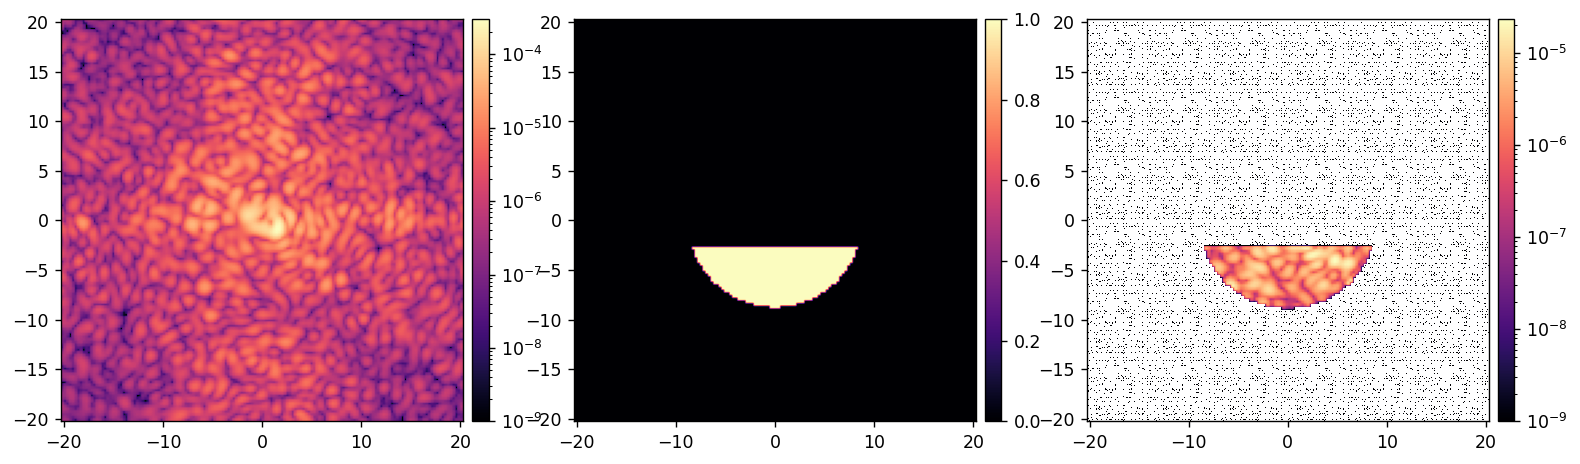

In [233]:
I.zero_dm()
I.NCAMSCI = 30
I.subtract_dark = True
I.return_ni = True
# I.set_zwo_exp_time(0.0005, client0)

ref_coro_im = I.snap_camsci()
ref_contrast = xp.mean(ref_coro_im[control_mask])
print(ref_contrast)
imshow(
    [ref_coro_im, control_mask, control_mask * ref_coro_im],
    norms=[LogNorm(1e-9), None, LogNorm(1e-9)],
    pxscls=[I.camlo_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)

In [234]:
I.zero_dm()
data = {
    'images':[ref_coro_im],
    'contrasts':[ref_contrast],
    'commands':[],
    'del_commands':[],
    'pixelscale':I.camsci_pxscl_lamDc,
    'control_mask':control_mask, 
    'probes':fourier_probes,
}

In [236]:
I.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


0.2
Running iEFC...
	Closed-loop iteration 28 / 30
0


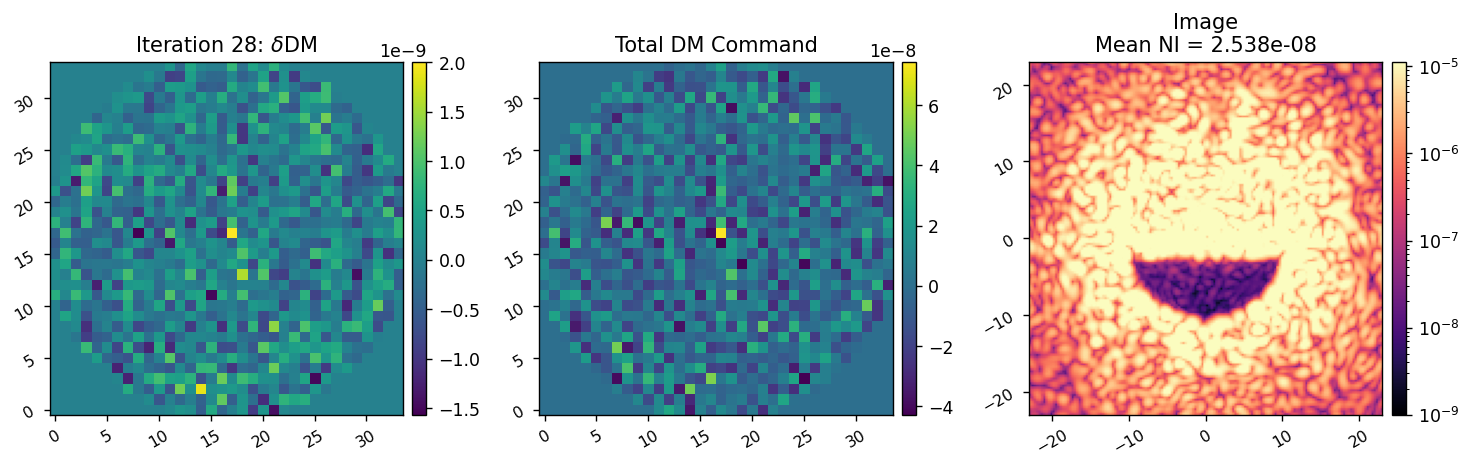

	Closed-loop iteration 29 / 30
0


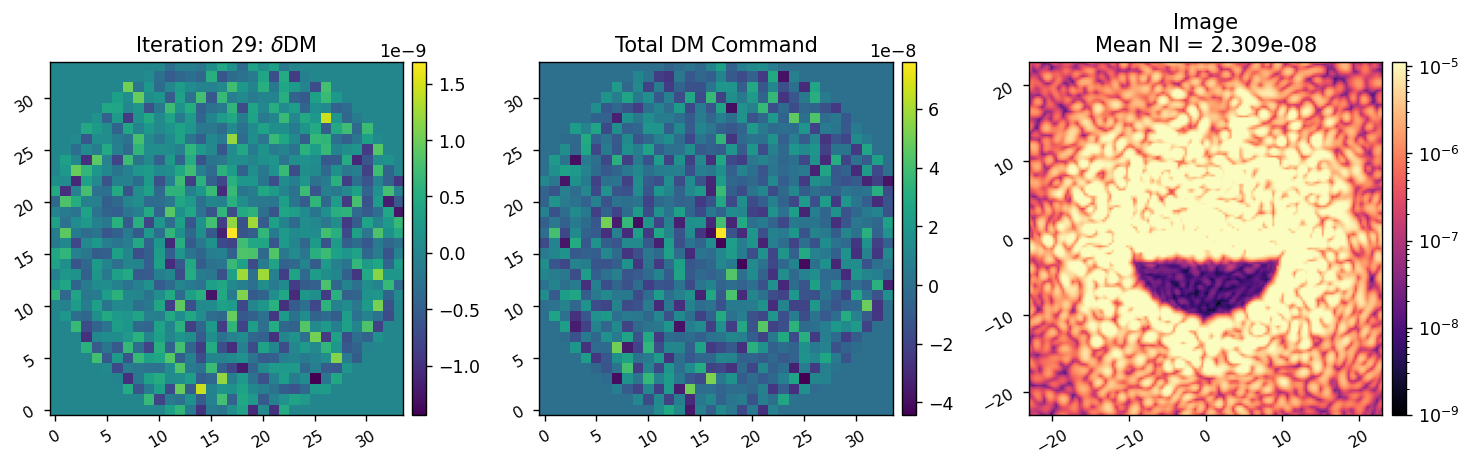

	Closed-loop iteration 30 / 30
0


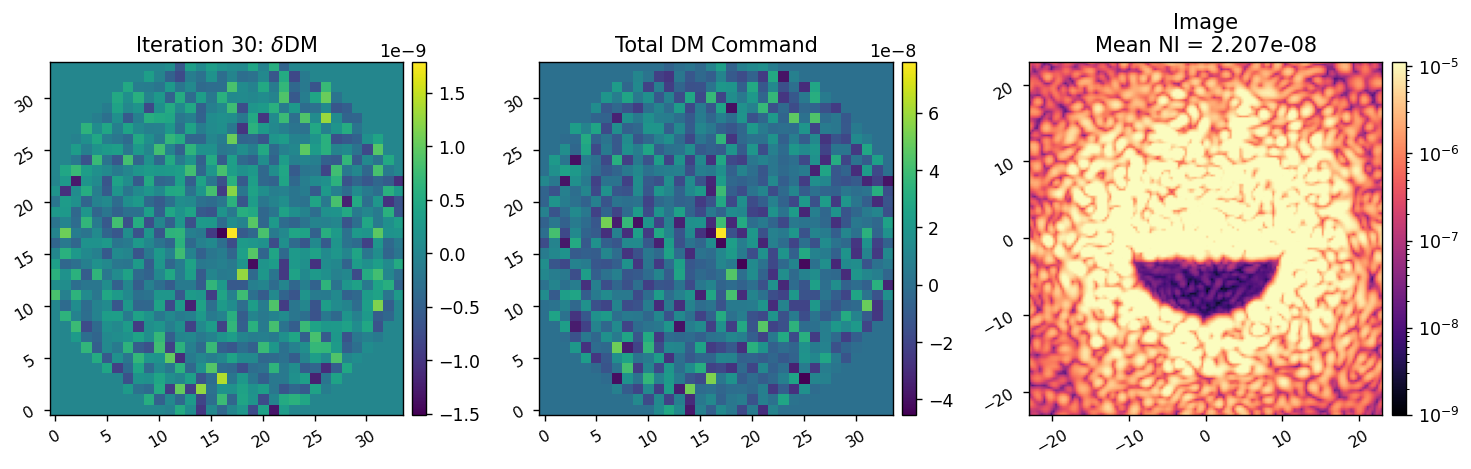

Closed loop for given control matrix completed in 54.583s.


In [249]:
reload(utils)
reload(iefc)

probe_amp = 5e-9
probe_amp = 4e-9
probe_amp = 3e-9
probe_amp = 2.5e-9
# probe_amp = 2e-9
# probe_amp = 1.5e-9
# probe_amp = 1e-9
# probe_amp = 0.75e-9
probe_amp = 0.5e-9
# probe_amp = 0.25e-9

I.NCAMSCI = 30
I.return_ni = True
I.dm_delay = 2*I.texp
print(I.dm_delay)

data = iefc.run(
    I,
    data,
    cm25,
    # cm50,
    # cm60,
    fourier_probes, 
    probe_amp, 
    calib_modes,
    control_mask,
    num_iterations=3,
    gain=0.75, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    plot_probes=False,
)

In [246]:
utils.save_pickle(data_path/f'{today}_iefc_run.pkl', data)


Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/20250319_iefc_run.pkl


0
3.0104428143980024e-08


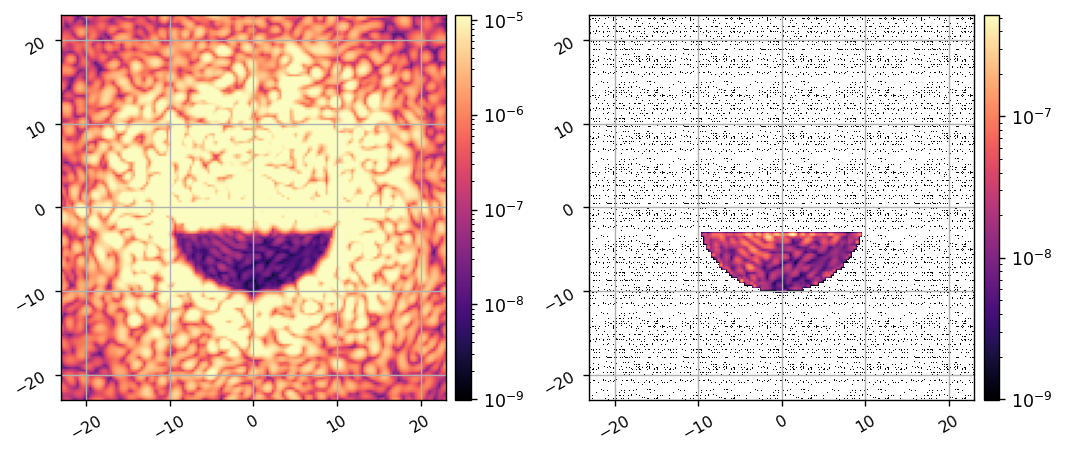

In [248]:
I.NCAMSCI = 50
I.subtract_dark = True
I.return_ni = True

coro_im = I.snap_camsci()
contrast = xp.mean(coro_im[control_mask])
print(contrast)
imshow2(coro_im, control_mask * coro_im, grid=True, lognorm=True, pxscl=I.camsci_pxscl_lamDc)

In [250]:
I.zero_dm()

In [251]:
I.set_camsci_exp_time(0.001, client0)

Set the ZWO exposure time to 1.00e-03s


# Make plot for LLOWFSC offset accuracy

In [ ]:
camlo_stream = ImageStream('camnsv')
camlo_ref_stream = ImageStream('camlo_ref_0')
camlo_ref_offset_stream = ImageStream('camlo_ref_offset')
camlo_ref_im0 = camlo_ref_stream.grab_latest()

In [ ]:
final_iefc_command = data['commands'][-1]
NCAMLO = 30
I.set_dm(final_iefc_command)
dark_hole_im = I.snap_camsci()
real_camlo_ref_im = camlo_stream.grab_many(NCAMLO)/NCAMLO
real_offset = real_camlo_ref_im - camlo_ref_im0
predicted_offset = camlo_ref_offset_stream.grab_latest()
offset_error = real_offset - predicted_offset

imshow3(
    real_offset,
    predicted_offset,
    offset_error, 
    grid=1,
)

In [ ]:
# offset_response_matrix = utils.load_pickle('exp-data/llowfsc_hsvd_calibration.pkl')
zer_calib_data = utils.load_pickle('exp-data/llowfsc_zernike_calibration.pkl')
zer_calib_modes = zer_calib_data['dm_modes']
control_matrix = zer_calib_data['control_matrix']
llowfsc_mask = zer_calib_data['llowfsc_mask']
offset_error_coeff = control_matrix.dot(offset_error[llowfsc_mask])
offset_error_opd = xp.sum( offset_error_coeff[:, None, None] * zer_calib_modes, axis=0)

I.add_dm(offset_error_opd)
dark_hole_im_with_lo_error = I.snap_camsci()

imshow2(
    offset_error_opd,
    dark_hole_im_with_lo_error,
    lognorm2=1,
    vmin2=1e-9,
)